# 신용카드 사기 탐지 분류 문제

- 목표 : 신용카드 거래 데이터를 활용하여 사기 거래를 탐지하는 이진 분류 모델 구축
- 평가지표 : F1-score

## 데이터셋 정보

2013년 9월 유럽 신용카드 사용자들의 거래 내역을 포함하고 있습니다.
이 데이터셋은 이틀 간의 거래 내역으로 데이터셋은 크게 불균형하며, 사기 거래(양성 클래스)는 전체 거래의 약 0.17%에 불과합니다.

이 데이터셋은 PCA 변환을 거친 수치형 변수들만 포함하고 있습니다. 안타깝게도 기밀 유지 문제로 인해 원본 특징과 데이터에 대한 자세한 배경 정보는 제공할 수 없습니다. V1, V2, …, V28은 PCA로 얻은 주성분이며, PCA 변환을 거치지 않은 유일한 특징은 'Time'과 'Amount'입니다. 'Time'은 각 거래와 데이터셋의 첫 거래 사이의 경과 시간(초)을 나타내며, 'Amount'는 거래 금액입니다. 'Amount' 특징은 예시 의존적 비용 민감 학습 등에 사용될 수 있습니다. 'Class'는 응답 변수로, 사기 거래인 경우 1, 그렇지 않은 경우 0의 값을 가집니다.

클래스 불균형 비율을 고려하여, 정밀도-재현율 곡선 아래 영역(AUPRC)을 사용하여 정확도를 측정할 것을 권장합니다. 불균형 분류에서는 혼동 행렬 정확도가 큰 의미가 없습니다.

이 데이터셋은 Worldline과 ULB(브뤼셀 자유 대학교) 머신러닝 그룹(http://mlg.ulb.ac.be) 간의 빅데이터 마이닝 및 사기 탐지 관련 연구 협력을 통해 수집 및 분석되었습니다.
관련 주제에 대한 현재 및 과거 프로젝트에 대한 자세한 내용은 https://www.researchgate.net/project/Fraud-detection-5 및 DefeatFraud 프로젝트 페이지에서 확인할 수 있습니다.

In [176]:
import numpy as np
import pandas as pd

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

## EDA

In [177]:
# 타겟 피처
train['Class'].value_counts(normalize=True) * 100

Class
0    99.78933
1     0.21067
Name: proportion, dtype: float64

타겟 피처의 약 0.21% 만 사기거래 데이터로, 불균형이 존재한다

<Axes: xlabel='Amount', ylabel='Count'>

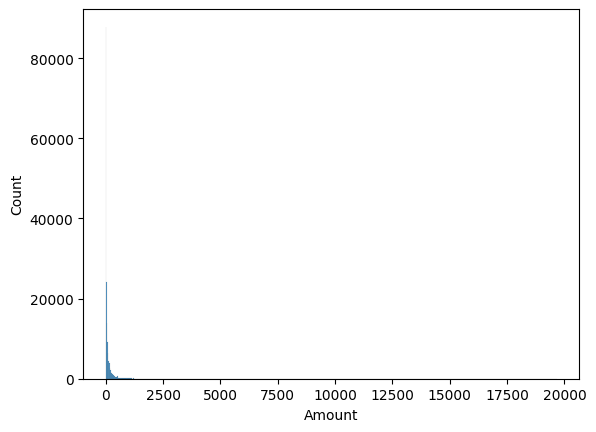

In [178]:
# Amount 피처
sns.histplot(train['Amount'])

데이터의 분포가 매우큰 우편포(right-skewed). 로그 변환이 필요해보임

In [179]:
train.corr()['Class'].sort_values(ascending=False)

Class     1.000000
V11       0.181917
V4        0.159813
V2        0.124537
V21       0.050751
V19       0.048401
V8        0.026687
V20       0.023689
V27       0.021196
V28       0.007481
Amount    0.004528
V22       0.003981
V26       0.002472
V23      -0.001187
V25      -0.001201
V13      -0.003224
V24      -0.006353
id       -0.006452
Time     -0.007334
V15      -0.010299
V6       -0.053041
V9       -0.114938
V5       -0.143884
V1       -0.145423
V18      -0.156770
V16      -0.256496
V7       -0.263719
V10      -0.275925
V3       -0.281337
V12      -0.287091
V14      -0.345635
V17      -0.412954
Name: Class, dtype: float64

몇 개의 pca 피처에서 타겟 피처와 높은 상관을 보임.

<Axes: xlabel='Time', ylabel='Count'>

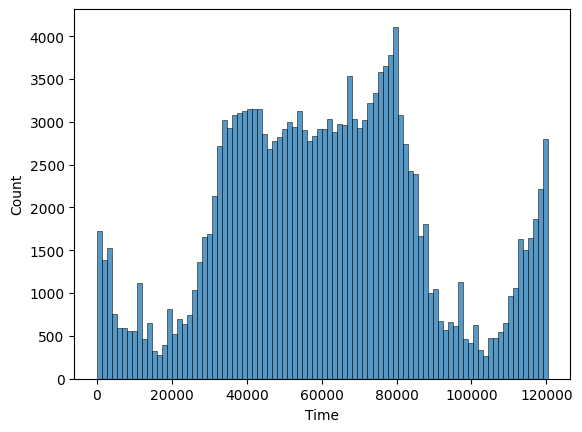

In [180]:
sns.histplot(train['Time'])

거래가 특정 시간대에 몰려있음. 해석가능한 정보로 변환이 필요 -> 거래 시간대

## 전처리

In [181]:
train['Amount'] = np.log1p(train['Amount'])
test['Amount']  = np.log1p(test['Amount'])

Amount feature를 로그변환하여 정규분포화/이상치 영향 완화

In [182]:
train['hour'] = (train['Time']//3600)%24
test['hour']  = (test['Time']//3600)%24

train.drop('Time', axis=1, inplace=True)
test.drop('Time', axis=1, inplace=True)

Time 피처를 거래 시간대(24시간 중)로 변환

## 학습 데이터 분할

In [223]:
X = train.drop(['Class','id'], axis=1)
y = train['Class']

In [224]:
X_test = test.drop('id', axis=1)

In [184]:
# 교차검증용 KFold
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 모델 
- 분할된 데이터를 통해 여러 모델들의 예측 성능을 비교
- 모델의 파라미터를 통해 불균형 데이터 문제를 어느정도 보완하여 학습

In [185]:
# threshold tuning 포함한 cv
from sklearn.metrics import f1_score

def cv_f1(model):
    
    scores = []
    
    for tr_idx, va_idx in skf.split(X, y):
        
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_va)[:,1]
        
        best = 0
        
        for t in np.arange(0.05, 0.5, 0.01):
            pred = (proba >= t).astype(int)
            best = max(best, f1_score(y_va, pred)) # fold 별 best threshold
        
        scores.append(best)
        
    return np.mean(scores), np.std(scores)

In [186]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

scale = (y==0).sum() / (y==1).sum()

models = {
    'Logistic Regression': LogisticRegression(max_iter=5000),
    
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced_subsample',
        n_jobs=-1,
        random_state=42
    ),
    
    'XGBoost': XGBClassifier(
        scale_pos_weight=scale,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),
    
    'LightGBM': LGBMClassifier(
        scale_pos_weight=scale,
        verbose=-1,
        random_state=42
    )
}

for name, model in models.items():
    
    mean, std = cv_f1(model)
    print(f'{name}: / f1_mean: {mean} / std: {std}')

Logistic Regression: / f1_mean: 0.7834999575419436 / std: 0.018228531362736694
Random Forest: / f1_mean: 0.8898807931085265 / std: 0.01649862377337783
XGBoost: / f1_mean: 0.8885248086283543 / std: 0.013319628571269025
LightGBM: / f1_mean: 0.08842317179020251 / std: 0.04041060768825264


- 결과, Radom Forest와 XGBoost의 성능이 가장 좋았고, 둘의 성능이 비슷했다

## SMOTE 오버샘플링을 활용하여 불균형 문제 해결
- 오버샘플링을 통해서 불균형 문제를 해결해보고 기존 방식의 모델과 성능을 비교했다

In [187]:
from imblearn.over_sampling import SMOTE

def cv_f1_smote(model):
    
    scores = []
    smote = SMOTE(random_state=42, k_neighbors=3)
    
    for tr_idx, va_idx in skf.split(X, y):
        
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        
        X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)
        
        model.fit(X_tr_sm, y_tr_sm)
        proba = model.predict_proba(X_va)[:,1]
        
        best = 0
        
        for t in np.arange(0.05, 0.5, 0.01):
            pred = (proba>=t).astype(int)
            best = max(best, f1_score(y_va, pred))
        
        scores.append(best)
        
    return np.mean(scores), np.std(scores)

In [188]:
models_smote = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        n_jobs=-1,
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        eval_metric='logloss',
        random_state=42
    )
}

smote_scores = {}

for name, model in models_smote.items():
    
    mean, std = cv_f1_smote(model)
    print(f'{name}: / f1_mean: {mean} / std: {std}')

Random Forest: / f1_mean: 0.8795566378181455 / std: 0.017595917114302608
XGBoost: / f1_mean: 0.864231743556015 / std: 0.02720946323830637


- 결과, 기존의 방식보다 평균 f1-score 가 .01~.02 소폭 하락하였다.
- 따라서 기존의 모델 파라미터를 통해 불균형 데이터의 웨이트를 조절하는 방식으로 불균형 문제를 다루는 것으로 결정했다

## 하이퍼 파라미터 튜닝 (HyperOpt)
- 튜닝해야하는 파라미터가 많은 XGBoost 등을 사용하기 때문에 GreedSearch 방식이 아닌 베이지안 방식으로 하이퍼 파라미터를 최적화

In [196]:
# 계산 시간 단축을 위해 split을 줄인 튜닝용 KFold
skf_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [197]:
# 튜닝용 cv 함수
def cv_f1_tune(model):

    scores = []

    for tr_idx, va_idx in skf_tune.split(X, y):

        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_va)[:,1]

        best = 0

        for t in np.arange(0.1, 0.4, 0.03): #  threshold 간격을 넓혀 계산시간 단축
            pred = (proba>=t).astype(int)
            best = max(best, f1_score(y_va, pred))

        scores.append(best)

    return np.mean(scores), np.std(scores)

In [200]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

def tune_rf(max_evals=40):
    space = {
        'n_estimators': hp.quniform('n_estimators', 200, 800, 50),
        'max_depth': hp.quniform('max_depth', 3, 20, 1),
        'min_samples_split': hp.quniform('min_samples_split', 2, 20, 1),
        'min_samples_leaf': hp.quniform('min_samples_leaf', 1, 10, 1),
        'max_features': hp.choice('max_features', ['sqrt', 'log2', None]),
    }

    trials = Trials()

    def objective(params):
        model = RandomForestClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            min_samples_split=int(params['min_samples_split']),
            min_samples_leaf=int(params['min_samples_leaf']),
            max_features=params['max_features'],
            class_weight='balanced_subsample',
            n_jobs=-1,
            random_state=42
        )
        mean, _ = cv_f1_tune(model)
        return {'loss': -mean, 'status': STATUS_OK}

    best = fmin(
        fn=objective,
        space=space,
        algo=tpe.suggest,
        max_evals=max_evals,
        trials=trials,
        rstate=np.random.default_rng(42)
    )

    best_model = RandomForestClassifier(
        n_estimators=int(best['n_estimators']),
        max_depth=int(best['max_depth']),
        min_samples_split=int(best['min_samples_split']),
        min_samples_leaf=int(best['min_samples_leaf']),
        max_features=['sqrt', 'log2', None][best['max_features']],
        class_weight='balanced_subsample',
        n_jobs=-1,
        random_state=42
    )

    return best_model, best, trials


def tune_xgb(max_evals=40):
    space = {
        'n_estimators': hp.quniform('n_estimators', 300, 900, 50),
        'max_depth': hp.quniform('max_depth', 3, 10, 1),
        'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
        'subsample': hp.uniform('subsample', 0.6, 1.0),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
        'reg_lambda': hp.uniform('reg_lambda', 0.0, 10.0),
        'reg_alpha': hp.uniform('reg_alpha', 0.0, 5.0),
        'min_child_weight': hp.uniform('min_child_weight', 1.0, 10.0),
        'gamma': hp.uniform('gamma', 0.0, 5.0),
    }

    trials = Trials()

    def objective(params):
        model = XGBClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            learning_rate=float(params['learning_rate']),
            subsample=float(params['subsample']),
            colsample_bytree=float(params['colsample_bytree']),
            reg_lambda=float(params['reg_lambda']),
            reg_alpha=float(params['reg_alpha']),
            min_child_weight=float(params['min_child_weight']),
            gamma=float(params['gamma']),
            scale_pos_weight=scale,
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1
        )
        mean, _ = cv_f1_tune(model)
        return {'loss': -mean, 'status': STATUS_OK}

    best = fmin(
        fn=objective,
        space=space,
        algo=tpe.suggest,
        max_evals=max_evals,
        trials=trials,
        rstate=np.random.default_rng(42)
    )

    best_model = XGBClassifier(
        n_estimators=int(best['n_estimators']),
        max_depth=int(best['max_depth']),
        learning_rate=float(best['learning_rate']),
        subsample=float(best['subsample']),
        colsample_bytree=float(best['colsample_bytree']),
        reg_lambda=float(best['reg_lambda']),
        reg_alpha=float(best['reg_alpha']),
        min_child_weight=float(best['min_child_weight']),
        gamma=float(best['gamma']),
        scale_pos_weight=scale,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )

    return best_model, best, trials

In [202]:
rf_tuned, rf_best, rf_trials = tune_rf(max_evals=40)
xgb_tuned, xgb_best, xgb_trials = tune_xgb(max_evals=40)

# 기존 cv로 모델 성능 확인
rf_mean, rf_std = cv_f1(rf_tuned)
xgb_mean, xgb_std = cv_f1(xgb_tuned)

100%|████████| 40/40 [02:31<00:00,  3.79s/trial, best loss: -0.8795696244599535]


In [203]:
# 모델 성능 출력
print(f'RF tuned  / f1_mean: {rf_mean} / std: {rf_std}')
print(f'XGB tuned / f1_mean: {xgb_mean} / std: {xgb_std}')

def robust_score(mean, std):
    return mean - std

print(f'RF robust:  {robust_score(rf_mean, rf_std)}')
print(f'XGB robust: {robust_score(xgb_mean, xgb_std)}')

RF tuned  / f1_mean: 0.8795596971227555 / std: 0.01117724403269793
XGB tuned / f1_mean: 0.8906882367125775 / std: 0.014735528586802346
RF robust:  0.8683824530900576
XGB robust: 0.8759527081257751
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


- 결과. 하이퍼 파라미터 튜닝을 통해 두 모델의 성능이 소폭 상승
- 그러나 두 모델의 성능이 비슷하여 두 모델을 함께 고려하는 앙상블 모델도 구축하여 비교

## 앙상블 모델 비교
- 소프트 보팅을 이용한 앙상블 모델을 구축
- 이후 성능 지표를 출력하여 기존 모델과 비교

In [210]:
def cv_f1_ensemble(rf_model, xgb_model, w_rf=0.5):
    scores = []
    w_xgb = 1.0 - w_rf

    for tr_idx, va_idx in skf.split(X, y):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        rf_model.fit(X_tr, y_tr)
        xgb_model.fit(X_tr, y_tr)

        rf_proba = rf_model.predict_proba(X_va)[:, 1]
        xgb_proba = xgb_model.predict_proba(X_va)[:, 1]

        ens_proba = w_rf * rf_proba + w_xgb * xgb_proba # soft voting

        best = 0
        for t in np.arange(0.01, 0.5, 0.01):
            pred = (ens_proba >= t).astype(int)
            best = max(best, f1_score(y_va, pred))

        scores.append(best)

    return np.mean(scores), np.std(scores)

In [211]:
mean, std = cv_f1_ensemble(rf_tuned, xgb_tuned, w_rf=0.5)

print(mean, std)

0.8928012316313279 0.011638300579410203


앙상블 모델의 성능이 더 좋음을 확인. 최종 모델로 앙상블 모델을 선택

## 최적 threshold
- train 데이터를 test처럼 예측하여 최적 threshold 찾기

In [214]:
oof_rf = np.zeros(len(y))
oof_xgb = np.zeros(len(y))

for tr_idx, va_idx in skf.split(X, y):

    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr = y.iloc[tr_idx]

    rf_tuned.fit(X_tr, y_tr)
    xgb_tuned.fit(X_tr, y_tr)

    oof_rf[va_idx] = rf_tuned.predict_proba(X_va)[:,1]
    oof_xgb[va_idx] = xgb_tuned.predict_proba(X_va)[:,1]


oof_ens = 0.5 * oof_rf + 0.5 * oof_xgb

In [215]:
best_t = 0
best_score = 0

for t in np.arange(0.01,0.4,0.01):

    pred = (oof_ens >= t).astype(int)
    score = f1_score(y, pred)

    if score > best_score:
        best_score = score
        best_t = t

print(best_t, best_score)

0.39 0.884180790960452


## 최종 예측

In [234]:
w_rf = 0.5
best_t = 0.39

rf_tuned.fit(X, y)
xgb_tuned.fit(X, y)

rf_test_proba = rf_tuned.predict_proba(X_test)[:, 1]
xgb_test_proba = xgb_tuned.predict_proba(X_test)[:, 1]

ens_test_proba = w_rf * rf_test_proba + (1.0 - w_rf) * xgb_test_proba
test_pred = (ens_test_proba >= best_t).astype(int)

submission = pd.DataFrame({'id': test['id'], 'Class': test_pred})
submission.to_csv('submission.csv', index=False)

- Kaggle score : 0.79681
- threshold를 관대하게 잡아서인지 확인하고자 낮추고 다시 제출. 점수 낮아짐

앙상블 모델 말고 단일 모델로 예측
- random forest 단독

In [240]:
best_t = 0.39

rf_tuned.fit(X, y)

# 확률 예측
rf_test_proba = rf_tuned.predict_proba(X_test)[:, 1]

# threshold 적용
test_pred = (rf_test_proba >= best_t).astype(int)

# 제출 파일 생성
submission = pd.DataFrame({
    'id': test['id'],
    'Class': test_pred
})

submission.to_csv('submission.csv', index=False)

print('pred fraud rate:', test_pred.mean())
print('fraud count:', test_pred.sum())

pred fraud rate: 0.0009216751665598694
fraud count: 105


- score : 0.82700